In [55]:
# import pandas as pd
# import numpy as np
# from faker import Faker

# # Initialize Faker and set seed
# fake = Faker()
# np.random.seed(42)

# # Number of rows
# n_rows = 5000

# # Generate synthetic data
# data = {
#     'N': np.random.uniform(0, 140, n_rows),           # Nitrogen ratio
#     'P': np.random.uniform(5, 145, n_rows),           # Phosphorous ratio
#     'K': np.random.uniform(5, 205, n_rows),           # Potassium ratio
#     'temperature': np.random.uniform(10, 45, n_rows), # Temperature in Celsius
#     'humidity': np.random.uniform(10, 90, n_rows),    # Relative Humidity in %
#     'ph': np.random.uniform(3.5, 9.5, n_rows),         # Soil pH
#     'rainfall': np.random.uniform(20, 300, n_rows)    # Rainfall in mm
# }

# # Crop labels
# crop_types = [
#     "rice", "wheat", "maize", "chickpea", "kidneybeans", "pigeonpeas",
#     "mothbeans", "mungbean", "blackgram", "lentil", "pomegranate", "banana",
#     "mango", "grapes", "watermelon", "muskmelon", "apple", "orange", "papaya",
#     "coconut", "cotton", "jute", "coffee"
# ]

# # Add to DataFrame and assign random labels
# df_soil = pd.DataFrame(data).round(2)
# df_soil['label'] = np.random.choice(crop_types, n_rows)

# # Save to CSV (optional)
# # df_soil.to_csv('synthetic_soil_crop_dataset.csv', index=False)

# print("Dataset created with 5000 rows and crop labels.")


In [56]:
import pandas as pd 
data= pd.read_csv("synthetic_soil_crop_dataset.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,52.44,60.11,79.73,27.49,68.40,4.05,198.68,blackgram
1,133.10,71.28,71.58,36.14,24.76,3.86,148.60,jute
2,102.48,124.64,40.23,29.69,37.73,7.13,290.06,papaya
3,83.81,52.60,126.45,12.92,63.06,9.30,81.31,mungbean
4,21.84,126.75,100.32,16.50,48.57,6.52,184.60,blackgram


In [57]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report



In [83]:
data=pd.read_csv('synthetic_soil_crop_dataset.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,52.44,60.11,79.73,27.49,68.40,4.05,198.68,blackgram
1,133.10,71.28,71.58,36.14,24.76,3.86,148.60,jute
2,102.48,124.64,40.23,29.69,37.73,7.13,290.06,papaya
3,83.81,52.60,126.45,12.92,63.06,9.30,81.31,mungbean
4,21.84,126.75,100.32,16.50,48.57,6.52,184.60,blackgram


In [58]:

df=pd.read_csv("synthetic_soil_crop_dataset.csv")

In [82]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,52.44,60.11,79.73,27.49,68.40,4.05,198.68,2
1,133.10,71.28,71.58,36.14,24.76,3.86,148.60,8
2,102.48,124.64,40.23,29.69,37.73,7.13,290.06,17
3,83.81,52.60,126.45,12.92,63.06,9.30,81.31,14
4,21.84,126.75,100.32,16.50,48.57,6.52,184.60,2
...,...,...,...,...,...,...,...,...
4995,125.64,125.07,135.18,40.70,36.20,9.21,141.63,9
4996,16.71,130.65,40.56,11.64,68.16,7.99,149.80,11
4997,45.90,137.54,15.25,20.63,83.86,3.62,168.31,19
4998,114.20,60.65,141.59,25.52,60.98,5.91,290.92,12


In [59]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [60]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,69.556454,73.808212,105.275072,27.769010,50.702206,6.447934,160.172002
std,40.548764,39.986279,58.153888,10.073223,23.099296,1.707292,80.731175
min,0.000000,5.010000,5.030000,10.010000,10.000000,3.500000,20.000000
25%,34.142500,39.602500,54.430000,19.197500,30.710000,4.980000,89.305000
50%,70.000000,73.035000,104.240000,27.935000,51.065000,6.450000,160.535000
75%,104.735000,107.672500,157.122500,36.290000,70.612500,7.890000,229.505000
max,139.960000,144.930000,204.960000,45.000000,89.990000,9.500000,299.940000


label encoding

In [61]:

le = LabelEncoder()
df['label']=le.fit_transform(df['label'])

feature seperate

In [62]:
input_data = df.drop(['label'], axis=1)
output_data = df['label']

In [63]:
X_train, X_test, y_train, y_test=train_test_split(input_data,output_data, test_size=0.2, random_state=42)


In [64]:
model=RandomForestClassifier(n_estimators=150,max_depth=18,min_samples_split=10,min_samples_leaf=3,random_state=42)
model.fit(input_data,output_data)



RandomForestClassifier(max_depth=18, min_samples_leaf=3, min_samples_split=10,
                       n_estimators=150, random_state=42)

In [65]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.99


In [66]:
train_score=model.score(X_train, y_train)
test_score=model.score(X_test, y_test)

In [67]:
train_score

0.99125

In [68]:
test_score

0.993

In [69]:
# cm= confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

In [70]:
# sns.pairplot(df, hue='label', vars=['N','P','K','temperature','humidity','ph','rainfall'])
# plt.show()

In [71]:
# df.drop(columns='label_encoded',inplace=True)

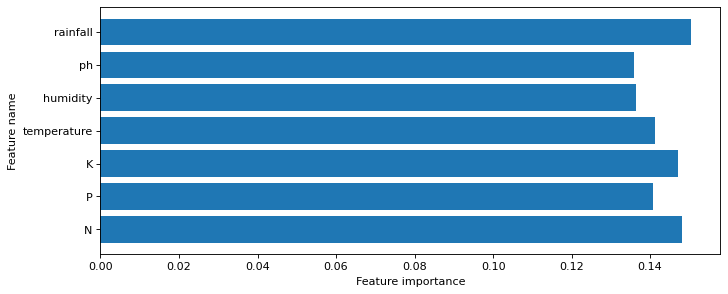

In [72]:
plt.figure(figsize=(10,4), dpi=80)
c_features = len(X_train.columns)
plt.barh(range(c_features), clf.feature_importances_)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.yticks(np.arange(c_features), X_train.columns)
plt.show()

In [73]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,52.44,60.11,79.73,27.49,68.40,4.05,198.68,2
1,133.10,71.28,71.58,36.14,24.76,3.86,148.60,8
2,102.48,124.64,40.23,29.69,37.73,7.13,290.06,17
3,83.81,52.60,126.45,12.92,63.06,9.30,81.31,14
4,21.84,126.75,100.32,16.50,48.57,6.52,184.60,2
...,...,...,...,...,...,...,...,...
4995,125.64,125.07,135.18,40.70,36.20,9.21,141.63,9
4996,16.71,130.65,40.56,11.64,68.16,7.99,149.80,11
4997,45.90,137.54,15.25,20.63,83.86,3.62,168.31,19
4998,114.20,60.65,141.59,25.52,60.98,5.91,290.92,12


In [74]:

joblib.dump(model, "crop_model.pkl") #random forest
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [90]:
new_data=[[52.44, 60.11, 79.73, 27.49, 68.40, 4.05, 198.68]]
input_df=pd.DataFrame(new_data)
prediction=model.predict(input_df)
crop_name=le.inverse_transform(prediction)[0]

print(crop_name)

blackgram


C:\Users\Aditya vachani\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [76]:
52.44	60.11	79.73	27.49	68.40	4.05	198.68	2

SyntaxError: invalid syntax (815448349.py, line 1)

In [ ]:
Random Forest works well for your dataset because:

It captures non-linear relationships well.

It handles feature interactions effectively.

It has built-in resistance to overfitting with proper tuning.

It performs well with structured/tabular data.

It can adapt to noise and imbalanced data effectively.

<Figure size 1200x1000 with 0 Axes>

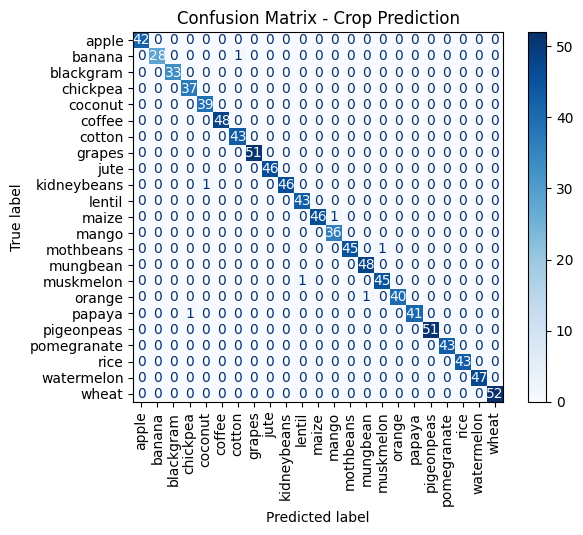

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you already have:
# model - your trained Random Forest model
# X_test, y_test - your test data

# Step 1: Predict on test data
y_pred = model.predict(X_test)

# Step 2: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 3: Display it with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(12, 10))
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - Crop Prediction")
plt.show()


In [80]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy
report = classification_report(y_test, y_pred, target_names=le.classes_)
print(report)


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        42
      banana       1.00      0.97      0.98        29
   blackgram       1.00      1.00      1.00        33
    chickpea       0.97      1.00      0.99        37
     coconut       0.97      1.00      0.99        39
      coffee       1.00      1.00      1.00        48
      cotton       0.98      1.00      0.99        43
      grapes       1.00      1.00      1.00        51
        jute       1.00      1.00      1.00        46
 kidneybeans       1.00      0.98      0.99        47
      lentil       0.98      1.00      0.99        43
       maize       1.00      0.98      0.99        47
       mango       0.97      1.00      0.99        36
   mothbeans       1.00      0.98      0.99        46
    mungbean       0.98      1.00      0.99        48
   muskmelon       0.98      0.98      0.98        46
      orange       1.00      0.98      0.99        41
      papaya       1.00    

In [81]:
accuracy

0.993